# 🏠 EMBER: Destination & Origin Analysis

This notebook demonstrates **destination inference, activity-based origin detection, and advanced analytics** using the EMBER package.  
It replicates the key analyses from Cova et al. (2024) — *"Destination unknown: Examining wildfire evacuee trips using GPS data"* — applied to the January 2025 LA Wildfires (Palisades & Eaton fires).

**Analyses covered:**
1. Destination inference from nightly stop data
2. Travel distance distributions (histogram + CDF)
3. Distance-decay curves by evacuee group
4. Evacuee group summary & destination counts
5. Destination type classification (parcel data, optional)
6. Group × type heatmaps (% trips + median distance)
7. Origin-destination movement maps
8. Activity-based origin inference (Nima et al. 2025)
9. K-S test: distance distribution comparison
10. Temporal destination evolution
11. Return behavior by destination type

**See also:** `01_evacuation_behavior.ipynb` for departure timing and behavioral classification.

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adjust path if running from examples/
sys.path.insert(0, os.path.abspath('..'))

import ember
from ember import io, destination, activities, metrics

print(f"EMBER v{ember.__version__}")

EMBER v0.2.0


## 1. Load Data

In [2]:
# Load evacuation metrics (pre-computed by the main pipeline)
evac_metrics = io.load_evacuation_metrics('data/evacuation_metrics.csv')
homes = io.load_homes('data/home.csv')

print(f"Evacuees loaded: {len(evac_metrics):,}")
print(f"Homes loaded:    {len(homes):,}")
evac_metrics.head()

Evacuees loaded: 9,297
Homes loaded:    66,519


,ID,Category,GroupId,DepartureDate,ReturnDate,DelayHours,ZoneType,OrderStart,FireEvent,SubRegion,home_lon,is_evacuee
0,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,NER,6,2025-01-05 19:00:00,2025-01-19 08:50:00,0.000000,Order,2025-01-08 06:09:00,Eaton,Eaton (Other),-1.315792e+07,False
1,0013c171-f175-3763-b3ef-e5a6e0081928,NER,6,NaT,NaT,NaN,Warning,2025-01-08 06:09:00,Palisades,Palisades,-1.316118e+07,False
2,0016c7e3-b4f0-3fad-bb36-ba588ea62dde,SEFN,5,2025-01-11 12:16:03,2025-01-14 00:15:00,97.767500,Buffer,2025-01-07 10:30:00,Palisades,Palisades,-1.320202e+07,True
3,001d30d2-140e-323a-bb75-fd3aa97256f2,SEFN,5,2025-01-09 20:13:00,2025-01-17 21:04:00,49.916667,Buffer,2025-01-07 18:18:00,Eaton,Eaton (Other),-1.314971e+07,True
4,002157c4-4fa3-33bf-8be9-7788188d31a8,NER,6,NaT,NaT,NaN,Warning,2025-01-08 06:09:00,Palisades,Palisades,-1.316333e+07,False


In [3]:
# Load fire zones for map overlays
fire_zones = io.load_fire_timeline('data/Fire_Timeline/')
print(f"Fire zone records: {len(fire_zones)}")

Fire zone records: 187


## 2. Build Nightly Stop Data

The destination algorithm needs **nightly stop data** — one record per evacuee per night showing where they stayed overnight. We extract this from the raw GPS pings during the fire period.

In [4]:
# Load raw GPS pings during the fire
dau = pd.read_csv('data/dau_during_fire.csv')
print(f"Raw pings: {len(dau):,}")
dau.head()

Raw pings: 32,578,795


,GRID,LAT,LONG,TIMESTAMP,GEOHASH,datetime,Date
0,000319d0-4c4b-36d5-b6c8-65549e19db69,34.410915,-118.443283,1736177114000,9q5gbb24p,2025-01-06 07:25:14,2025-01-06
1,000319d0-4c4b-36d5-b6c8-65549e19db69,34.413055,-118.426926,1736177125000,9q5gc0sns,2025-01-06 07:25:25,2025-01-06
2,000319d0-4c4b-36d5-b6c8-65549e19db69,34.410912,-118.430511,1738022220000,9q5gc03d1,2025-01-27 15:57:00,2025-01-27
3,000319d0-4c4b-36d5-b6c8-65549e19db69,34.400002,-118.400002,1738022820000,9q5g9wrdx,2025-01-27 16:07:00,2025-01-27
4,000319d0-4c4b-36d5-b6c8-65549e19db69,34.407711,-118.432213,1738161924000,9q5g9p8r3,2025-01-29 06:45:24,2025-01-29


In [5]:
# Rename columns if needed to match EMBER schema
col_map = {}
if 'GRID' in dau.columns:         col_map['GRID'] = 'ID'
if 'LAT' in dau.columns:          col_map['LAT'] = 'latitude'
if 'LONG' in dau.columns:         col_map['LONG'] = 'longitude'
if 'TIMESTAMP' in dau.columns:    col_map['TIMESTAMP'] = 'timestamp_ms'
if col_map:
    dau = dau.rename(columns=col_map)

if 'datetime' not in dau.columns:
    dau['datetime'] = pd.to_datetime(dau['timestamp_ms'], unit='ms', utc=True)

print(f"Columns: {list(dau.columns)}")
print(f"Date range: {dau['datetime'].min()} to {dau['datetime'].max()}")

Columns: ['ID', 'latitude', 'longitude', 'timestamp_ms', 'GEOHASH', 'datetime', 'Date']
Date range: 2025-01-05 16:00:00 to 2025-02-01 15:59:00


In [6]:
# Build nightly stops using incremental clustering
# For each evacuee, cluster their pings and extract overnight activity locations

from ember.activities import incremental_cluster, haversine_m

# Get home locations as a dict for quick lookup
home_lookup = {}
for _, row in homes.iterrows():
    uid = row.get('GRID', row.get('ID', None))
    if uid is not None:
        home_lookup[uid] = (row['home_lat_4326'], row['home_lon_4326'])

# Only process evacuees (those in evac_metrics)
evacuee_ids = set(evac_metrics['ID'].unique())
dau_evac = dau[dau['ID'].isin(evacuee_ids)].copy()
print(f"Processing {dau_evac['ID'].nunique()} evacuees from {len(dau_evac):,} pings")

Processing 9297 evacuees from 4,464,738 pings


In [7]:
# Extract nightly stops: for each evacuee, for each night, find the cluster
# where they spent the most time between 8 PM and 7 AM

nightly_stops = []

for uid, user_pings in dau_evac.groupby('ID'):
    if uid not in home_lookup:
        continue
    
    # Cluster all pings for this user  
    clusters = incremental_cluster(
        user_pings, R_a=200, T_a='5min',
        lat_col='latitude', lon_col='longitude', time_col='datetime'
    )
    
    for c in clusters:
        # Consider clusters that overlap with nighttime (8 PM - 7 AM)
        c_hour_start = c.start_time.hour if hasattr(c.start_time, 'hour') else 0
        duration_min = (c.end_time - c.start_time).total_seconds() / 60
        
        # Use cluster date as the stop date
        stop_date = str(c.start_time.date())
        
        nightly_stops.append({
            'ID': uid,
            'stop_lat_4326': c.centroid_lat,
            'stop_lon_4326': c.centroid_lon,
            'stop_date': stop_date,
            'duration': duration_min,
            'n_points': c.n_points,
        })

stops_df = pd.DataFrame(nightly_stops)
print(f"Extracted {len(stops_df):,} activity stops from {stops_df['ID'].nunique()} evacuees")
stops_df.head()

/Users/mustafasameen/UF Dropbox/Mustafa Sameen/projects/LA Fire/ember/ember/activities.py:108: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  times = pd.to_datetime(df[time_col], utc=True)
/Users/mustafasameen/UF Dropbox/Mustafa Sameen/projects/LA Fire/ember/ember/activities.py:108: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  times = pd.to_datetime(df[time_col], utc=True)
/Users/mustafasameen/UF Dropbox/Mustafa Sameen/projects/LA Fire/ember/ember/activities.py:108: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  times = pd.to_datetime(df[time_col], utc=True)
/Users/mustafasa

Extracted 201,639 activity stops from 9088 evacuees


,ID,stop_lat_4326,stop_lon_4326,stop_date,duration,n_points
0,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.183601,-118.296303,2025-01-05,14.0,12
1,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.183601,-118.296303,2025-01-05,5.0,6
2,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.183601,-118.296303,2025-01-05,578.0,24
3,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.183601,-118.296303,2025-01-06,181.0,11
4,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.209999,-118.199997,2025-01-06,199.0,2


## 3. Infer Destinations

The `destination.infer_destinations()` function implements the Cova et al. (2024) algorithm:
1. Pick the longest-duration stop per night
2. Filter out stops within the home buffer
3. Merge successive stops closer than 0.4 km
4. Compute Euclidean distance from home

In [8]:
# Prepare homes DataFrame with matching ID column
homes_for_dest = homes.rename(columns={'GRID': 'ID'}) if 'GRID' in homes.columns else homes.copy()
if 'ID' not in homes_for_dest.columns and homes_for_dest.index.name == 'ID':
    homes_for_dest = homes_for_dest.reset_index()

# Run destination inference
dest_df = destination.infer_destinations(
    stops_df,
    homes_for_dest,
    merge_distance_km=0.4,
    home_buffer_m=400,
)

print(f"\nInferred {len(dest_df):,} destinations for {dest_df['ID'].nunique()} evacuees")
print(f"\nDistance stats (km):")
print(dest_df['eu_distance_km'].describe())
dest_df.head(10)


Inferred 30,922 destinations for 7895 evacuees

Distance stats (km):
count    30922.000000
mean        28.679949
std         77.006144
min          0.401000
25%          2.338250
50%          7.287000
75%         23.017000
max        976.871000
Name: eu_distance_km, dtype: float64


,ID,dest_lat,dest_lon,dest_date,eu_distance_km,dest_order
0,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.183601,-118.296303,2025-01-05,9.709,1
1,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.051399,-118.270699,2025-01-09,19.714,2
2,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.183601,-118.296303,2025-01-11,9.709,3
3,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.032017,-118.244194,2025-01-17,21.154,4
4,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,33.950001,-118.290001,2025-01-18,31.010,5
5,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.029999,-118.290001,2025-01-24,22.566,6
6,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.040001,-118.279999,2025-01-25,21.198,7
7,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.099998,-118.300003,2025-01-27,16.105,8
8,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.040001,-118.300003,2025-01-30,21.908,9
9,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.070000,-118.269997,2025-01-31,17.753,10


In [9]:
# Merge behavioral category from evacuation metrics onto destinations
dest_with_cat = dest_df.merge(
    evac_metrics[['ID', 'Category', 'ZoneType']].drop_duplicates(subset=['ID']),
    on='ID', how='left'
)

# Merge home coordinates for OD map later
dest_with_cat = dest_with_cat.merge(
    homes_for_dest[['ID', 'home_lat_4326', 'home_lon_4326']].drop_duplicates(subset=['ID']),
    on='ID', how='left'
)

print(f"Categories found: {dest_with_cat['Category'].value_counts().to_dict()}")

Categories found: {'NER': 21864, 'SEFN': 4706, 'PERE': 2512, 'SELE': 675, 'FEUO': 645, 'FEUW': 520}


---
## 4. Travel Distance Analysis

### 4.1 Distance Histogram with CDF (All Groups) — *Fig. 9*

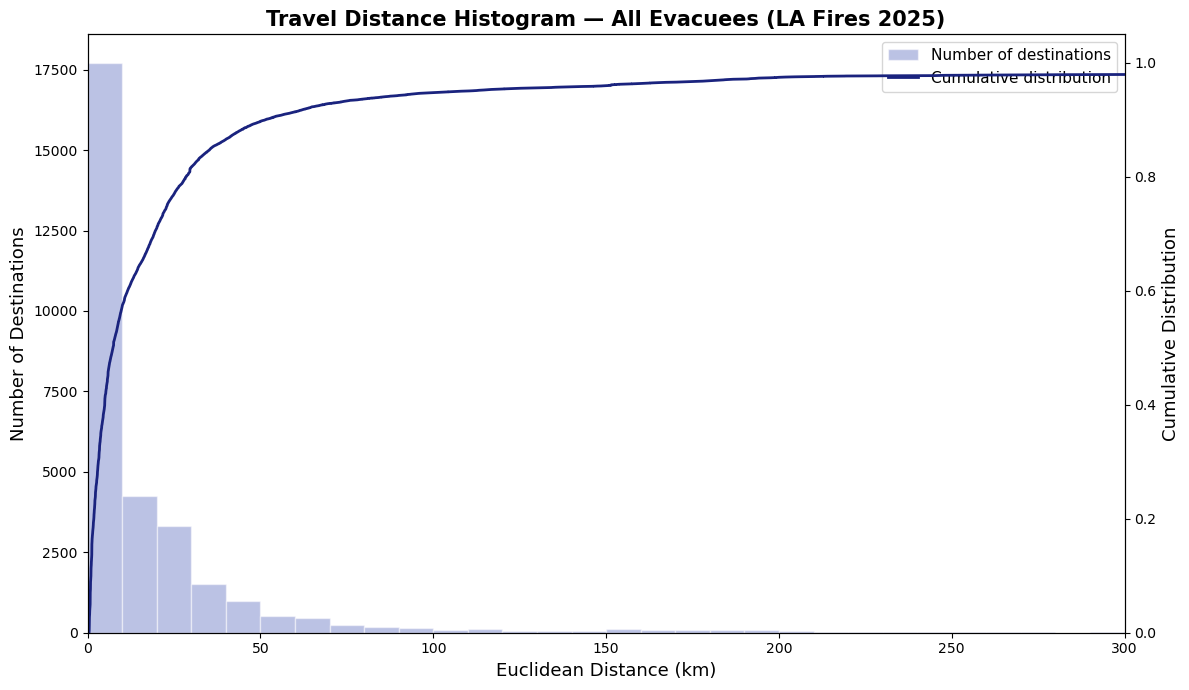

In [10]:
metrics.plot_distance_histogram(
    dest_with_cat,
    max_km=300,
    bin_width=10,
    title='Travel Distance Histogram — All Evacuees (LA Fires 2025)'
)

### 4.2 Distance Histogram + CDF by Group — *Fig. 10*

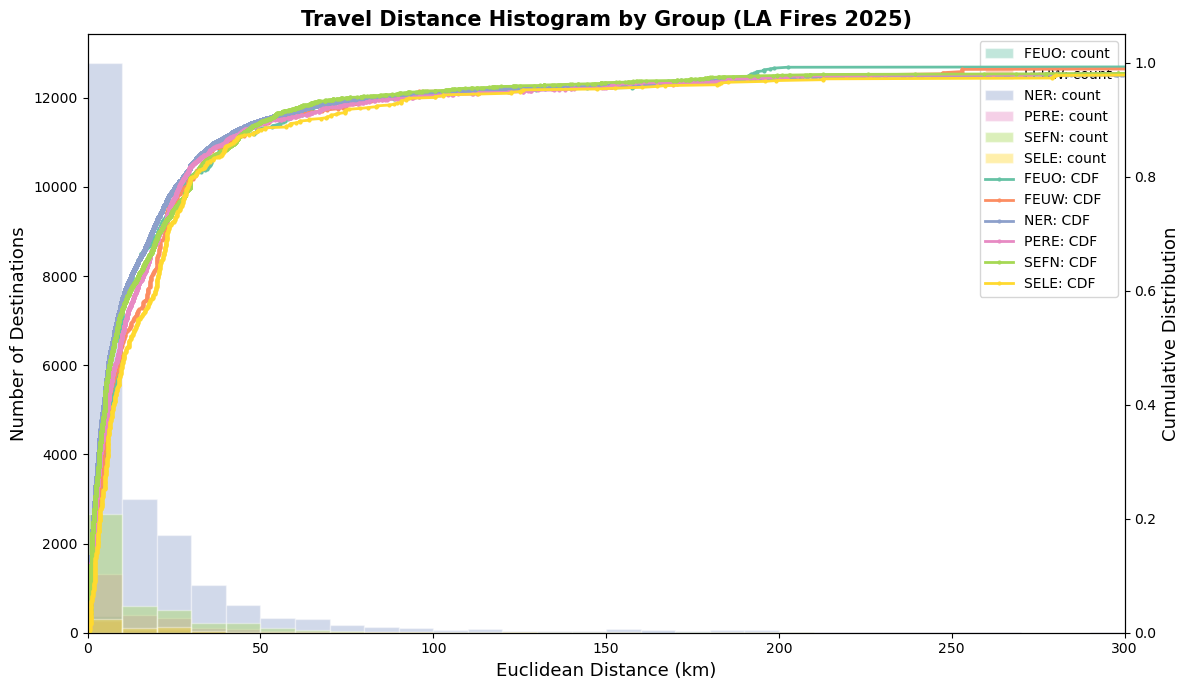

In [11]:
metrics.plot_distance_histogram(
    dest_with_cat,
    group_col='Category',
    max_km=300,
    bin_width=10,
    title='Travel Distance Histogram by Group (LA Fires 2025)'
)

### 4.3 Distance-Decay Curves by Group — *Fig. 11*

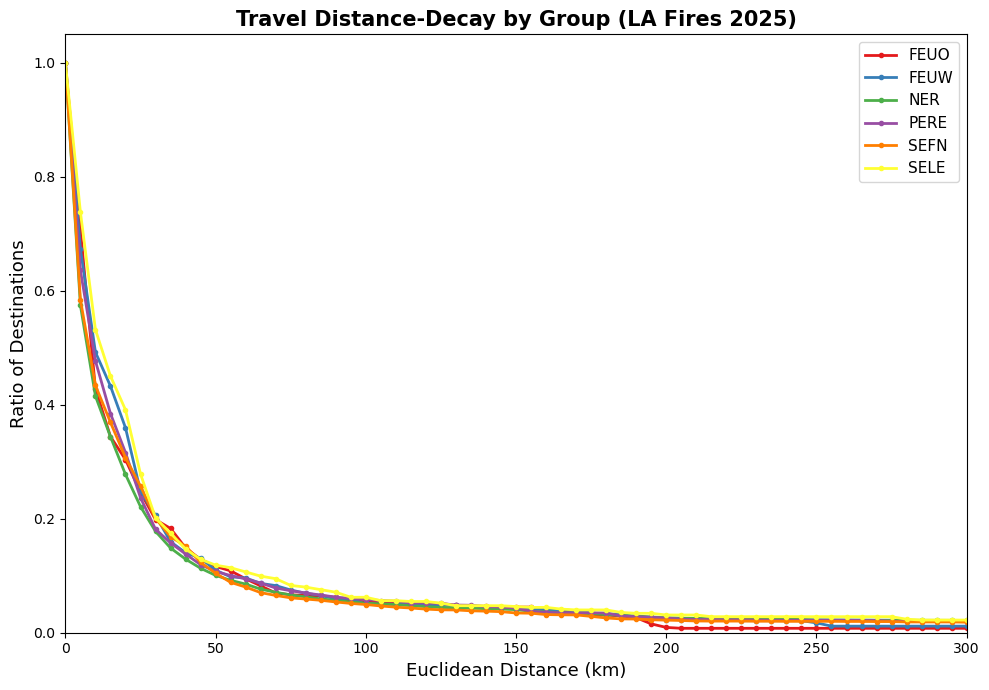

In [12]:
metrics.plot_distance_decay(
    dest_with_cat,
    group_col='Category',
    max_km=300,
    title='Travel Distance-Decay by Group (LA Fires 2025)'
)

---
## 5. Evacuee Groups and Destination Summary — *Fig. 4*

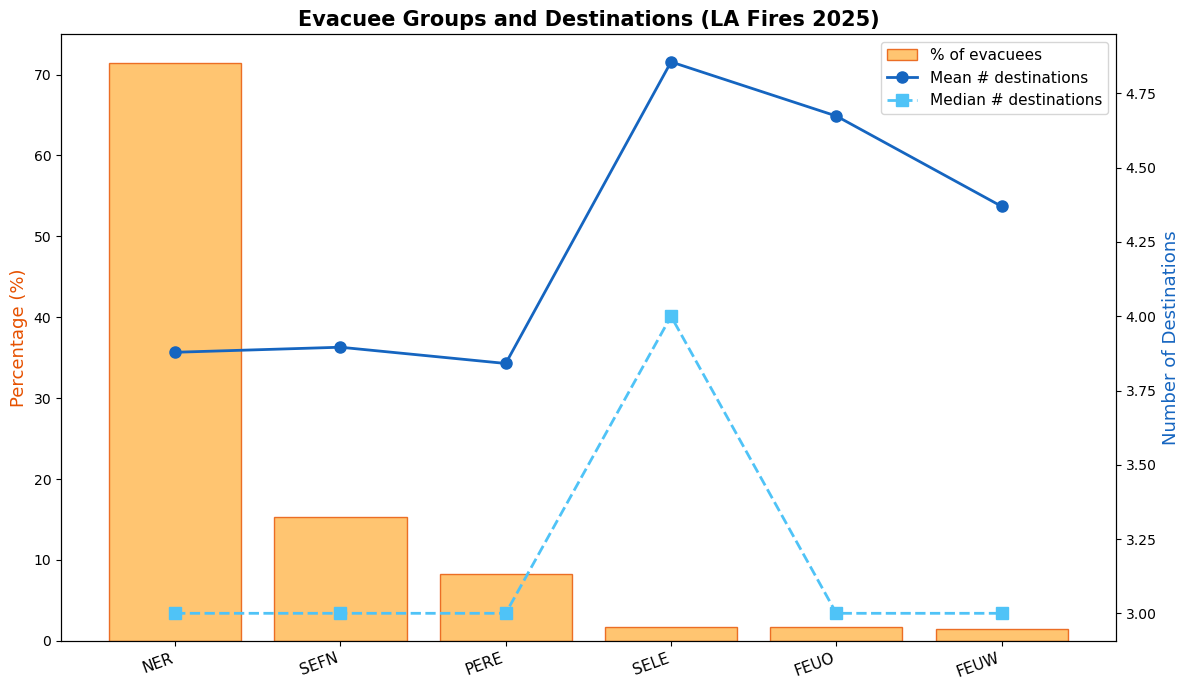

In [13]:
metrics.plot_evacuee_group_summary(
    dest_with_cat,
    group_col='Category',
    title='Evacuee Groups and Destinations (LA Fires 2025)'
)

### 5.1 Number of Destinations per Evacuee

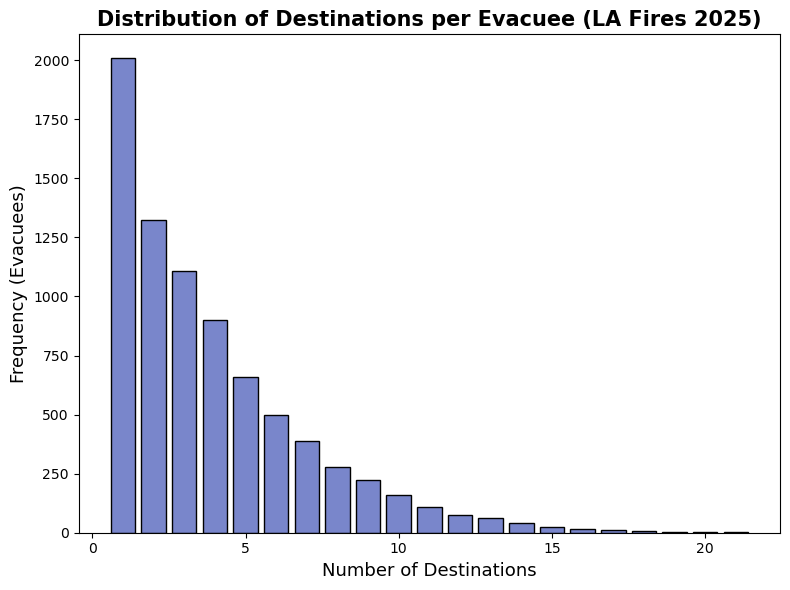

In [14]:
metrics.plot_destination_count(
    dest_with_cat,
    title='Distribution of Destinations per Evacuee (LA Fires 2025)'
)

---
## 6. Destination Type Classification (Optional: Parcel Data)

If county parcel/land-use data is available, the destination types can be classified. This section demonstrates both paths.

> **Note:** If you do not have parcel data, skip to Section 7.

In [15]:
PARCEL_PATH = 'data/LA_County/General_Plan_Land_Use/General_Plan_Land_Use.shp'


parcels = None
if PARCEL_PATH and os.path.exists(PARCEL_PATH):
    parcels = io.load_parcels(PARCEL_PATH)
    print(f"Loaded {len(parcels):,} parcels")
else:
    print("No parcel data available — destination types will not be classified.")
    print("To enable type classification, set PARCEL_PATH above.")

Loaded 52,330 parcels


In [16]:
# Classify destinations (works with or without parcel data)
dest_classified = destination.classify_destinations(
    dest_with_cat,
    parcels=parcels,
    dest_lat_col='dest_lat',
    dest_lon_col='dest_lon',
)

print(f"Destination type distribution:")
print(dest_classified['dest_type'].value_counts(dropna=False))

Destination type distribution:
dest_type
NaN            23018
residential     4308
open space      1481
commercial      1247
public           527
industrial       290
other             51
Name: count, dtype: int64


### 6.1 Destination Types — All Destinations — *Fig. 5*

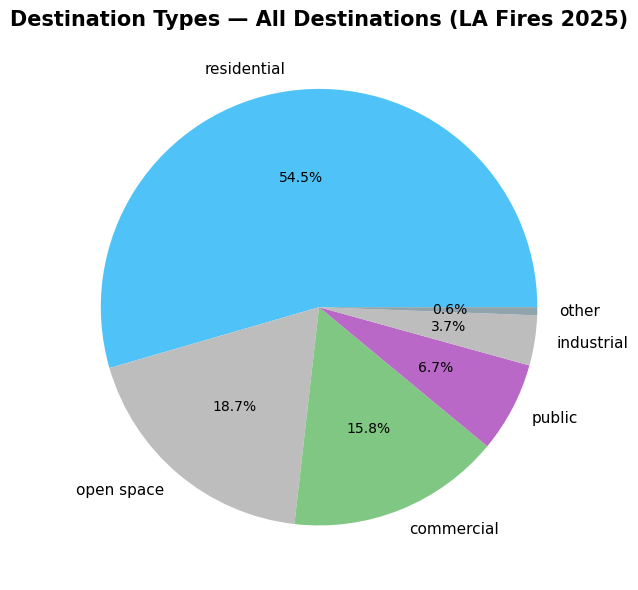

In [17]:
if dest_classified['dest_type'].notna().any():
    metrics.plot_destination_types(
        dest_classified,
        title='Destination Types — All Destinations (LA Fires 2025)'
    )
else:
    print("Skipping: No parcel data — destination types are not classified.")

### 6.2 Destination Types: ≤30 km — *Fig. 6*

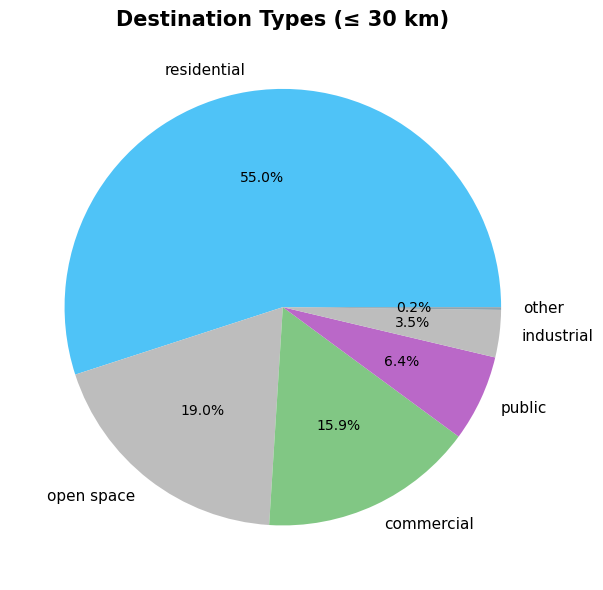

In [18]:
if dest_classified['dest_type'].notna().any():
    metrics.plot_destination_types(
        dest_classified,
        distance_threshold=30, threshold_mode='leq',
        title='Destination Types (≤ 30 km)'
    )
else:
    print("Skipping: No parcel data.")

### 6.3 Destination Types: >30 km — *Fig. 7*

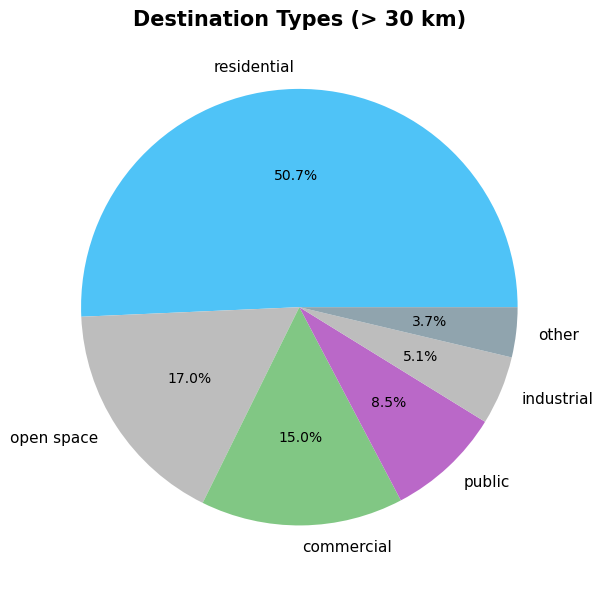

In [19]:
if dest_classified['dest_type'].notna().any():
    metrics.plot_destination_types(
        dest_classified,
        distance_threshold=30, threshold_mode='gt',
        title='Destination Types (> 30 km)'
    )
else:
    print("Skipping: No parcel data.")

### 6.4 Comparison: ≤30 km vs >30 km — *Fig. 8*

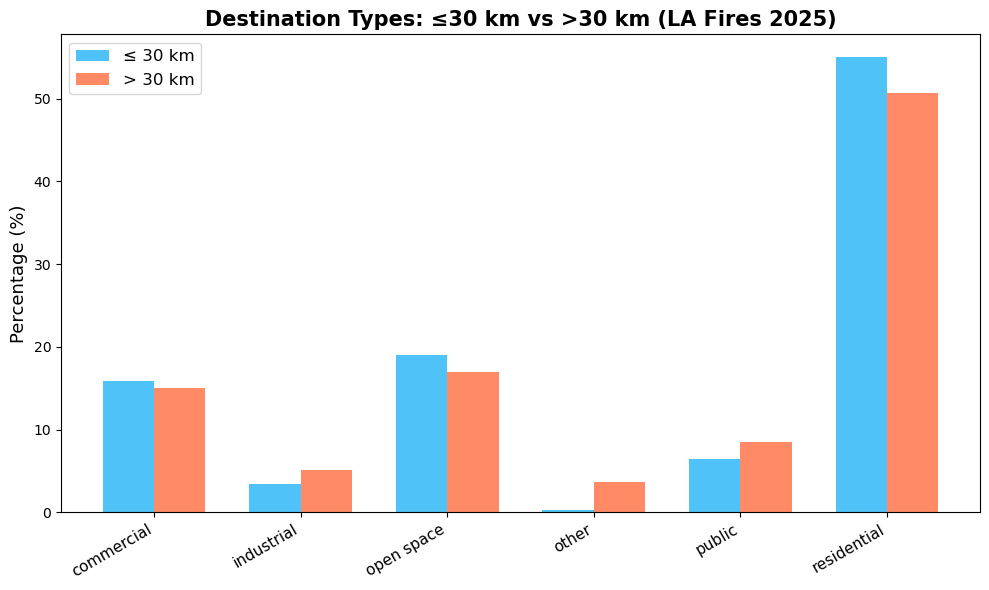

In [20]:
if dest_classified['dest_type'].notna().any():
    metrics.plot_dest_type_comparison(
        dest_classified,
        threshold_km=30,
        title='Destination Types: ≤30 km vs >30 km (LA Fires 2025)'
    )
else:
    print("Skipping: No parcel data.")

### 6.5 Group × Destination Type: Percent of Trips — *Fig. 15*

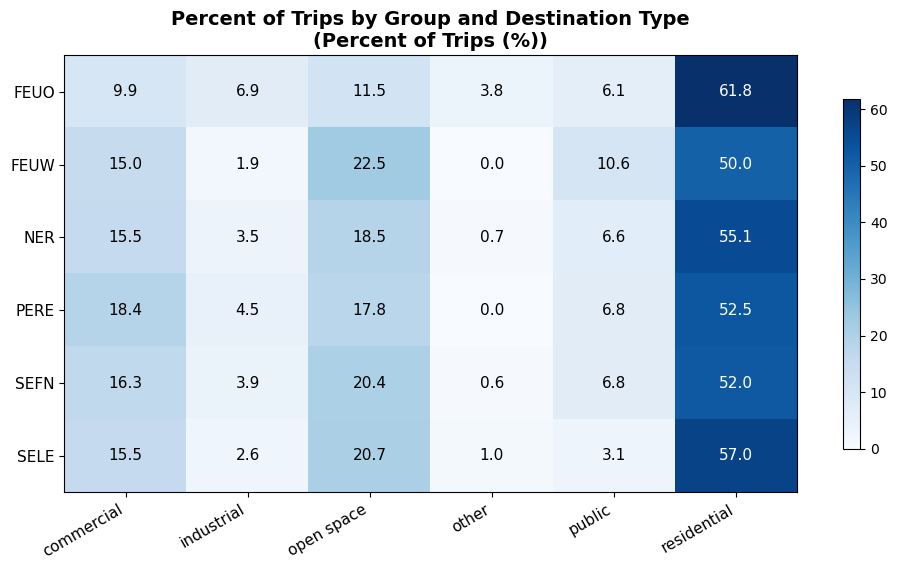

In [21]:
if dest_classified['dest_type'].notna().any():
    metrics.plot_group_dest_heatmap(
        dest_classified,
        group_col='Category',
        metric='pct',
        title='Percent of Trips by Group and Destination Type'
    )
else:
    print("Skipping: No parcel data.")

### 6.6 Group × Destination Type: Median Distance — *Fig. 16*

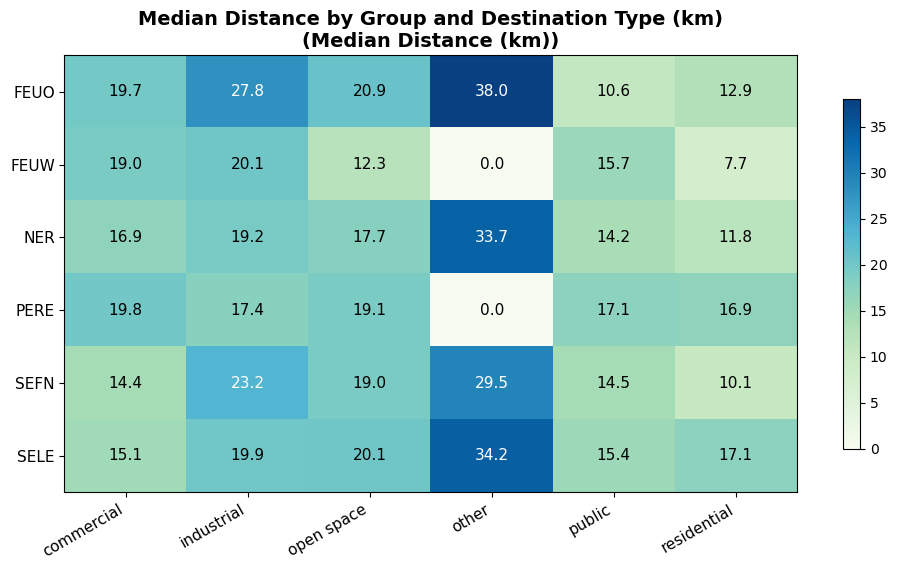

In [22]:
if dest_classified['dest_type'].notna().any():
    metrics.plot_group_dest_heatmap(
        dest_classified,
        group_col='Category',
        metric='median_distance',
        title='Median Distance by Group and Destination Type (km)'
    )
else:
    print("Skipping: No parcel data.")

---
## 7. Origin-Destination Maps — *Fig. 12/13/14*

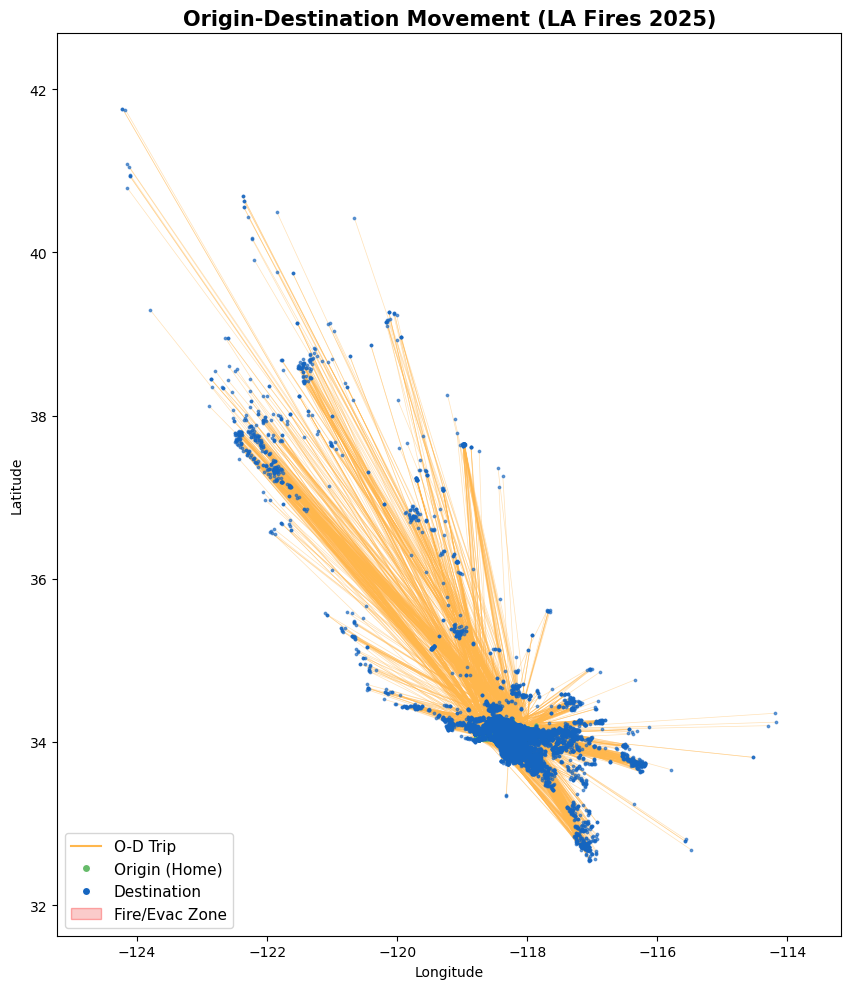

In [23]:
# Full O-D movement map (Fig. 12 — county/region scale)
metrics.plot_od_map(
    dest_with_cat,
    fire_zones=fire_zones,
    title='Origin-Destination Movement (LA Fires 2025)'
)

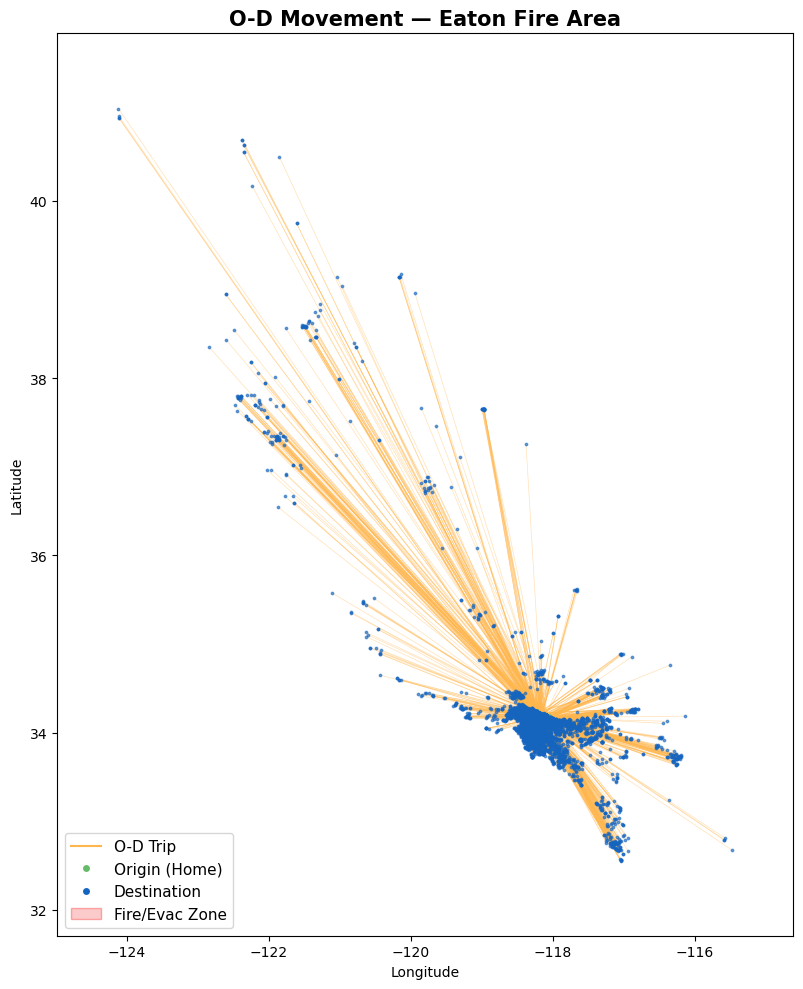

In [24]:
# Zoom into Eaton fire area
import geopandas as gpd

eaton_zones = fire_zones[fire_zones['zoneId'].str.contains('Eaton', case=False, na=False)] \
    if 'zoneId' in fire_zones.columns else fire_zones

# Filter destinations near Eaton (Altadena/Pasadena area)
eaton_dest = dest_with_cat[
    (dest_with_cat['home_lat_4326'].between(34.1, 34.25)) &
    (dest_with_cat['home_lon_4326'].between(-118.25, -118.05))
]

if not eaton_dest.empty:
    metrics.plot_od_map(
        eaton_dest,
        fire_zones=eaton_zones,
        title='O-D Movement — Eaton Fire Area'
    )

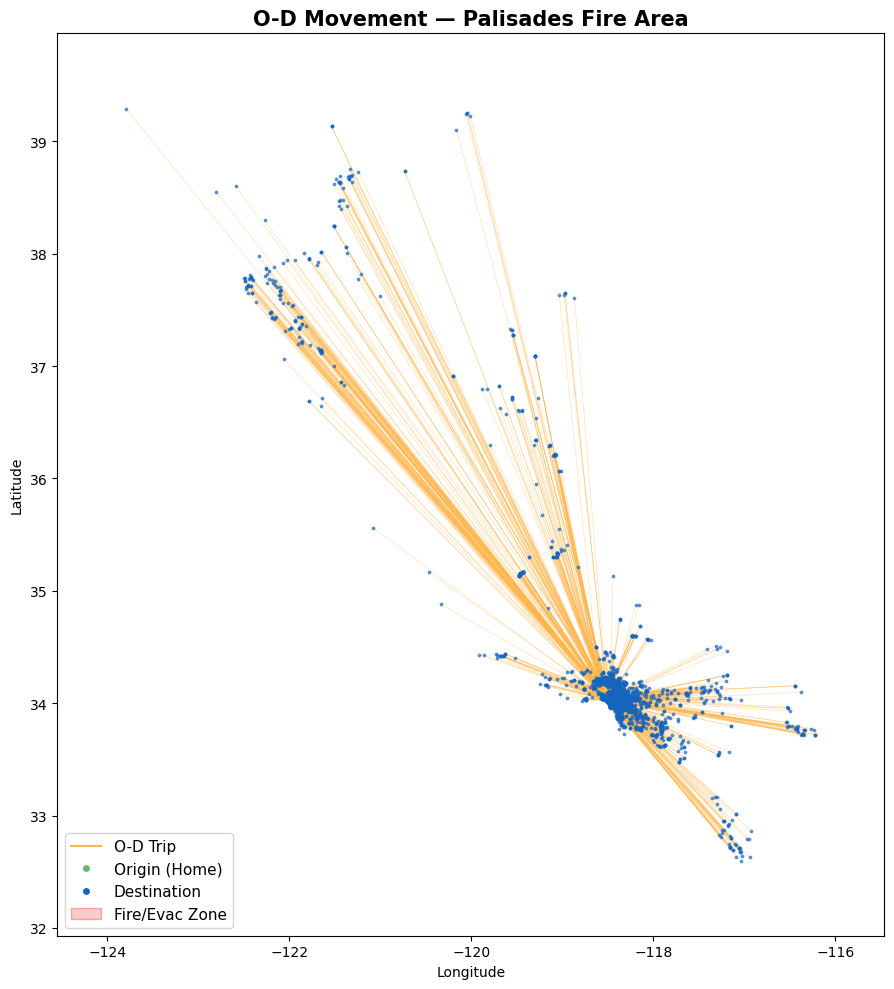

In [25]:
# Zoom into Palisades fire area
palisades_zones = fire_zones[fire_zones['zoneId'].str.contains('Palisades', case=False, na=False)] \
    if 'zoneId' in fire_zones.columns else fire_zones

palisades_dest = dest_with_cat[
    (dest_with_cat['home_lat_4326'].between(33.95, 34.1)) &
    (dest_with_cat['home_lon_4326'].between(-118.6, -118.4))
]

if not palisades_dest.empty:
    metrics.plot_od_map(
        palisades_dest,
        fire_zones=palisades_zones,
        title='O-D Movement — Palisades Fire Area'
    )

---
## 8. Activity-Based Origin Inference (Nima et al. 2025)

EMBER supports **activity-based origin detection**: instead of assuming all evacuees departed from home, it uses incremental clustering to find where the evacuee actually was at the time the fire started.

This is particularly relevant for rapid-onset wildfires where evacuees may have been at work, shopping, or other activities.

In [26]:
from ember.activities import find_origin

# Pick a sample of evacuees to demonstrate activity-based origin
sample_ids = dau_evac['ID'].unique()[:50]  # first 50 evacuees

# Fire start times for both fires
fire_starts = {
    'Palisades': pd.Timestamp('2025-01-07 10:30:00', tz='US/Pacific'),
    'Eaton': pd.Timestamp('2025-01-07 18:15:00', tz='US/Pacific'),
}

origins = []
for uid in sample_ids:
    if uid not in home_lookup:
        continue
    
    h_lat, h_lon = home_lookup[uid]
    user_pings = dau_evac[dau_evac['ID'] == uid]
    
    # Use the earliest fire start as reference
    fire_start = fire_starts['Palisades'].tz_convert('UTC')
    
    o_lat, o_lon, o_type = find_origin(
        user_pings, h_lat, h_lon,
        fire_start=fire_start,
        R_a=200, T_a='5min', home_radius=200
    )
    
    origins.append({
        'ID': uid,
        'origin_lat': o_lat, 'origin_lon': o_lon,
        'origin_type': o_type,
        'home_lat': h_lat, 'home_lon': h_lon,
    })

origins_df = pd.DataFrame(origins)
print(f"Origins inferred: {len(origins_df)}")
print(f"\nOrigin type breakdown:")
print(origins_df['origin_type'].value_counts())

Origins inferred: 50

Origin type breakdown:
origin_type
home        42
activity     8
Name: count, dtype: int64


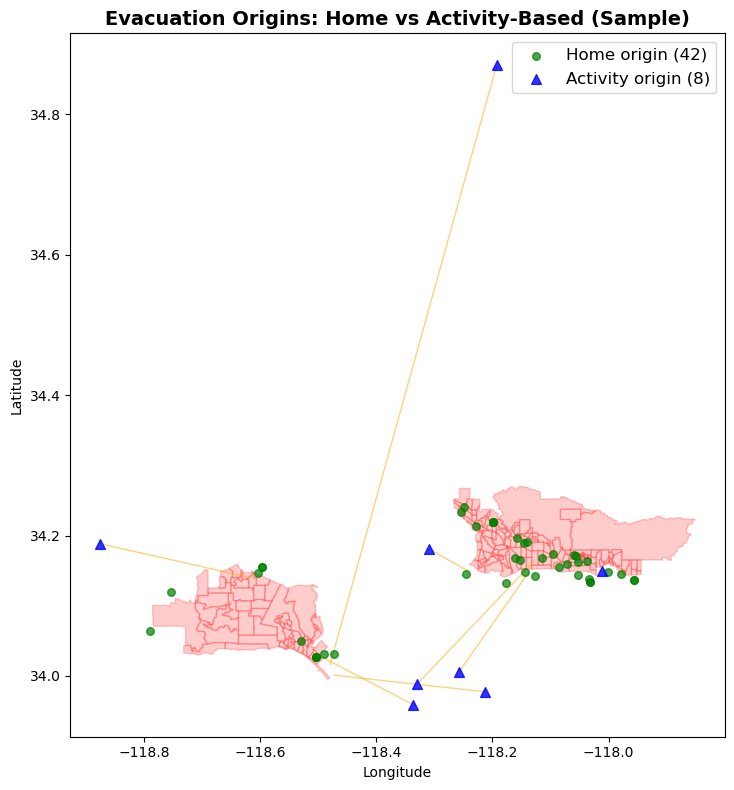

In [27]:
# Visualize: Home vs Activity origins on a map
try:
    import geopandas as gpd
    from shapely.geometry import Point
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot fire zones
    fire_zones.to_crs('EPSG:4326').plot(ax=ax, color='red', alpha=0.2, edgecolor='red')
    
    # Plot origins
    home_origins = origins_df[origins_df['origin_type'] == 'home']
    act_origins = origins_df[origins_df['origin_type'] == 'activity']
    
    if not home_origins.empty:
        ax.scatter(home_origins['origin_lon'], home_origins['origin_lat'],
                  c='green', s=30, alpha=0.7, label=f'Home origin ({len(home_origins)})', zorder=3)
    if not act_origins.empty:
        ax.scatter(act_origins['origin_lon'], act_origins['origin_lat'],
                  c='blue', s=50, marker='^', alpha=0.8, label=f'Activity origin ({len(act_origins)})', zorder=4)
        # Draw lines from home to activity origin
        for _, row in act_origins.iterrows():
            ax.plot([row['home_lon'], row['origin_lon']],
                   [row['home_lat'], row['origin_lat']],
                   color='orange', alpha=0.5, linewidth=1)
    
    ax.legend(fontsize=12)
    ax.set_title('Evacuation Origins: Home vs Activity-Based (Sample)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Map plotting requires geopandas: {e}")

---
## 9. K-S Test: Distance Distribution Comparison

Kolmogorov-Smirnov tests comparing travel-distance distributions between all pairs of evacuee groups. The heatmap shows KS statistics with significance stars.

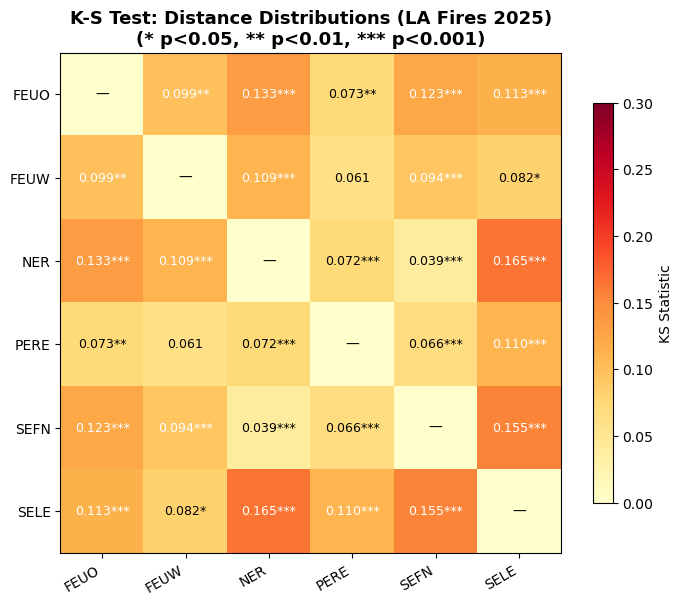

,Group_A,Group_B,KS_Statistic,p_value,Significant (p<0.05),n_A,n_B
0,FEUO,FEUW,0.0986,0.006764,True,645,520
1,FEUO,NER,0.1332,0.000000,True,645,21864
2,FEUO,PERE,0.0734,0.007456,True,645,2512
3,FEUO,SEFN,0.1228,0.000000,True,645,4706
4,FEUO,SELE,0.1125,0.000421,True,645,675
5,FEUW,NER,0.1094,0.000009,True,520,21864
6,FEUW,PERE,0.0606,0.080444,False,520,2512
7,FEUW,SEFN,0.0942,0.000451,True,520,4706
8,FEUW,SELE,0.0818,0.036562,True,520,675
9,NER,PERE,0.0716,0.000000,True,21864,2512


In [28]:
ks_results = metrics.ks_test_distances(
    dest_with_cat,
    group_col='Category',
    title='K-S Test: Distance Distributions (LA Fires 2025)'
)
ks_results

---
## 10. Temporal Destination Analysis

Track how evacuation destinations evolve over the fire timeline — do evacuees move further away or closer to home as the fire progresses?

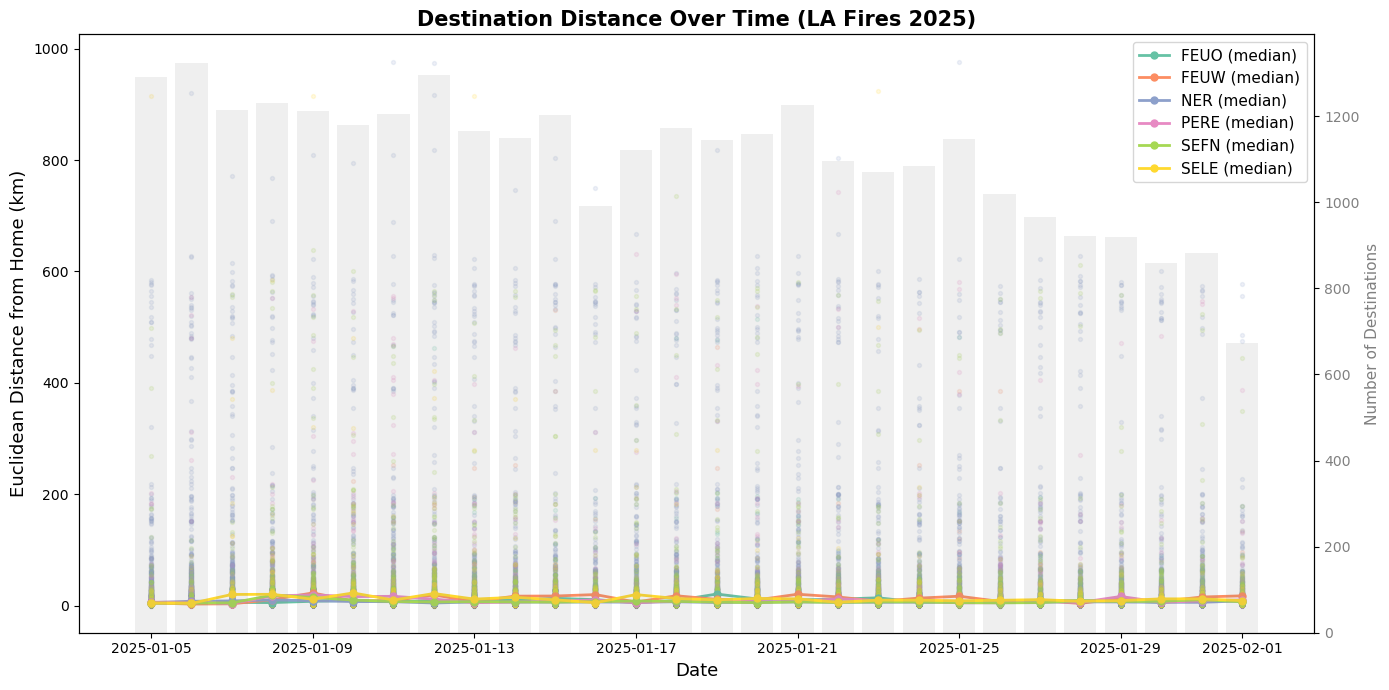

In [29]:
metrics.plot_temporal_destinations(
    dest_with_cat,
    group_col='Category',
    title='Destination Distance Over Time (LA Fires 2025)'
)

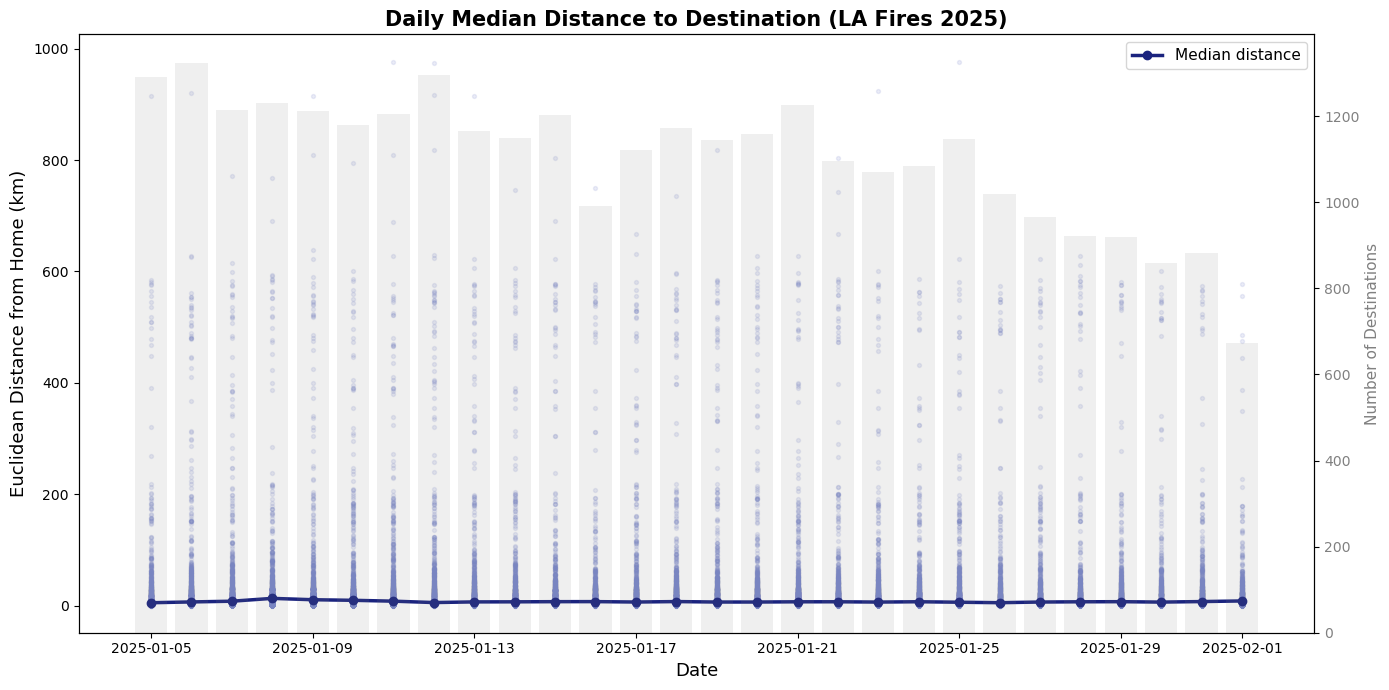

In [30]:
# Overall (without group breakdown)
metrics.plot_temporal_destinations(
    dest_with_cat,
    title='Daily Median Distance to Destination (LA Fires 2025)'
)

---
## 11. Return Behavior by Destination

Analyze the relationship between where evacuees went and when they returned home. Does destination type or distance predict how long evacuees stay away?

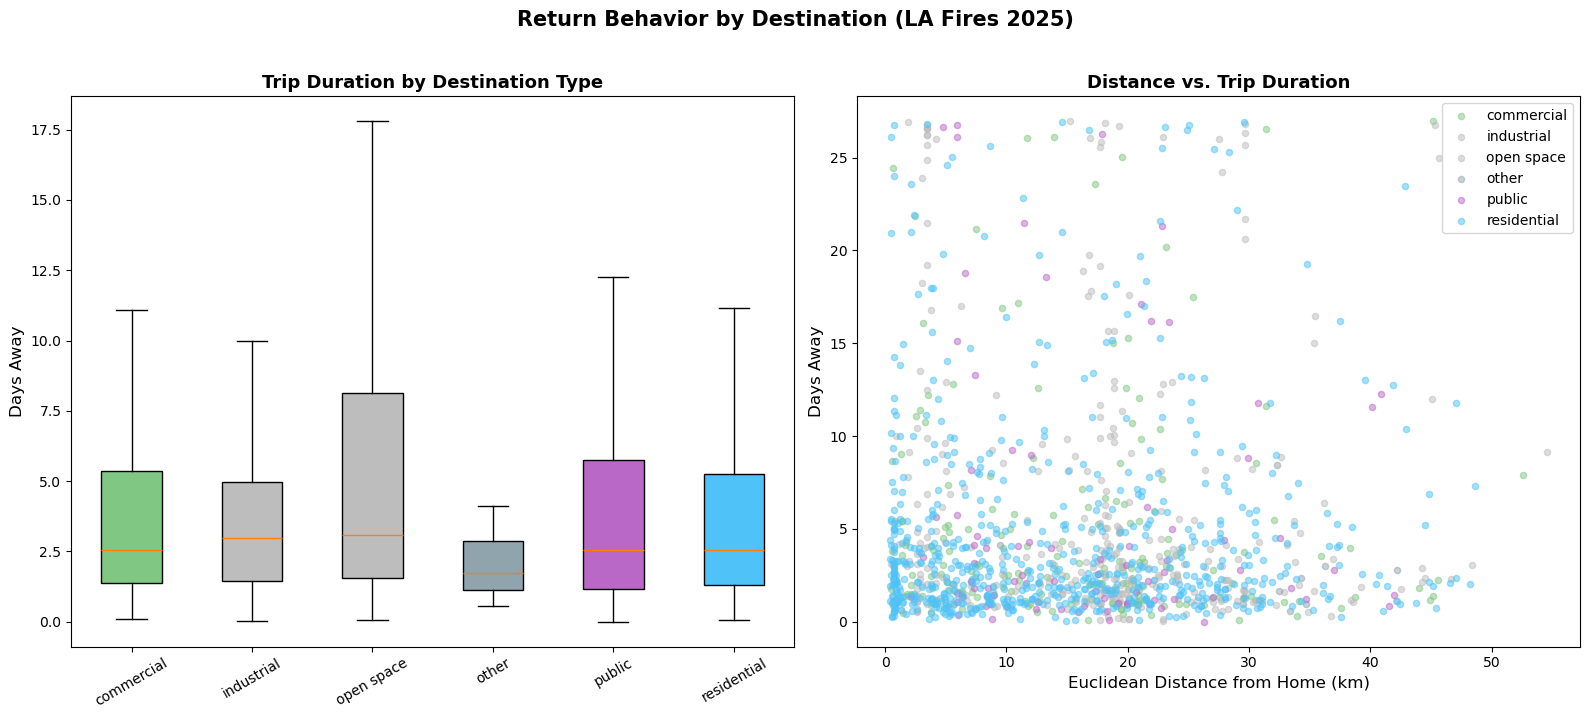

In [31]:
metrics.plot_return_by_destination(
    dest_classified,
    evac_metrics,
    title='Return Behavior by Destination (LA Fires 2025)'
)

---
## 12. Summary Statistics

In [32]:
print("=" * 60)
print("DESTINATION ANALYSIS SUMMARY — LA Wildfires 2025")
print("=" * 60)
print(f"Total evacuees analyzed:       {dest_df['ID'].nunique():,}")
print(f"Total destinations inferred:   {len(dest_df):,}")
print(f"Mean destinations / evacuee:   {dest_df.groupby('ID').size().mean():.2f}")
print(f"Median destinations / evacuee: {dest_df.groupby('ID').size().median():.1f}")
print(f"\nDistance from home (km):")
print(f"  Mean:   {dest_df['eu_distance_km'].mean():.1f}")
print(f"  Median: {dest_df['eu_distance_km'].median():.1f}")
print(f"  Max:    {dest_df['eu_distance_km'].max():.1f}")
print(f"  ≤ 30 km: {(dest_df['eu_distance_km'] <= 30).mean()*100:.1f}%")
print(f"  > 30 km:  {(dest_df['eu_distance_km'] > 30).mean()*100:.1f}%")

DESTINATION ANALYSIS SUMMARY — LA Wildfires 2025
Total evacuees analyzed:       7,895
Total destinations inferred:   30,922
Mean destinations / evacuee:   3.92
Median destinations / evacuee: 3.0

Distance from home (km):
  Mean:   28.7
  Median: 7.3
  Max:    976.9
  ≤ 30 km: 81.7%
  > 30 km:  18.3%


In [33]:
# Distance stats by category
if 'Category' in dest_with_cat.columns:
    print("\nDistance by Category:")
    print(dest_with_cat.groupby('Category')['eu_distance_km'].agg(['count', 'mean', 'median', 'max']).round(1))


Distance by Category:
          count  mean  median    max
Category                            
FEUO        645  26.1     9.4  514.9
FEUW        520  28.0     9.6  531.7
NER       21864  28.7     6.8  976.9
PERE       2512  29.3     9.4  742.2
SEFN       4706  27.6     7.4  735.8
SELE        675  35.1    11.5  924.1
